# BioJEPA v0.7 Training Pipeline

In [1]:
import torch
import random
import gc
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import numpy as np

from biojepa_v0_7 import BioJepa, BioJepaConfig
from dataloader_v0_7 import EncoderLoader, ComposerLoader, TrainingLoader
from training_v0_7 import create_model, load_feature_banks, run_encoder_training, run_composer_training, run_ac_training, train_linear_decoder, maybe_compile
from config_v0_7 import EncoderTrainingConfig, ComposerTrainingConfig, ACTrainingConfig, DecoderConfig, DataConfig
from evals.evals import EvalContext, run_encoder_evals, run_composer_evals, run_ac_evals, save_report

## Device & Paths

In [2]:
SEED = 1337

def get_device():
    device = 'cpu'
    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)
        device = 'cuda'
    print(f'using {device}')
    return torch.device(device)

torch.manual_seed(SEED)
random.seed(SEED)
torch.set_float32_matmul_precision('high')

device = get_device()

USE_AMP = torch.cuda.is_available()
USE_COMPILE = torch.cuda.is_available()
USE_FUSED = torch.cuda.is_available()

data_root = Path('~/data/jepa/v0_7').expanduser()
ref_root = Path('~/data/jepa/reference_data').expanduser()

data_cfg = DataConfig(
    data_root=data_root,
    checkpoint_dir=data_root / 'checkpoint',
    ref_dir = ref_root,
    eval_results_dir=data_root / 'eval_results'
)

using cpu


## Hyperparameters

In [3]:
# Model architecture
model_cfg = BioJepaConfig(
    num_genes=10000,
    n_layer=6,
    heads=4,
    embed_dim=256,
    mlp_ratio=4.0,
    n_pre_layer=2,
    mask_ratio=0.766,
    gaussian_scale=2.38,
    film_linear_multiple=0.81,
    sim_coeff=40.5,
    std_coeff=40.5,
    cov_coeff=1.62,
    pert_latent_dim=128,
    pert_mode_dim=64,
)

# Encoder training: WSD schedule with context L2 polish in last 2 epochs (v0.6 VICReg + no EMA freeze)
encoder_cfg = EncoderTrainingConfig(
    epochs=50, lr=1e-4, batch_size=64, phase2_start_pct=0.8, context_coeff=2.0, context_ramp_pct=0.04, ema_final_momentum=None,
)

# Composer training: InfoNCE loss with modality-balanced sampling (v0.7 HPO v8 winner)
composer_cfg = ComposerTrainingConfig(
    epochs=10000, lr=3.6e-4, batch_size=64, weight_decay=0.003, temperature=0.00126, chemical_fraction=0.1,
)

# AC training: mask annealing in final 20%, composer barely updated
ac_cfg = ACTrainingConfig(
    epochs=20, predictor_lr=1e-4, batch_size=32, mask_anneal_pct=0.2, mask_anneal_floor=0.0, composer_lr_mult=0.01,
)

decoder_cfg = DecoderConfig(epochs=10, lr=1e-3, batch_size=32)

## Initialize Model & Data

In [ ]:
model = create_model(model_cfg, device)
model = maybe_compile(model, USE_COMPILE)
seq_banks, target_bank = load_feature_banks(data_cfg, device)

print(f'Student/Teacher: {sum(p.numel() for p in model.student.parameters() if p.requires_grad):,}')
print(f'ACpredictor: {sum(p.numel() for p in model.predictor.parameters() if p.requires_grad):,}')
print(f'PerturbationComposer: {sum(p.numel() for p in model.composer.parameters() if p.requires_grad):,}')

### Load pretraining model from checkpoint (for resuming)

In [ ]:
# checkpoint_path = data_cfg.checkpoint_dir / 'biojepa_v0_7_ac_final.pt'
# with torch.serialization.safe_globals([BioJepaConfig]):
#     checkpoint = torch.load(checkpoint_path, map_location=device)

# keys = model.load_state_dict(checkpoint['model'])
# keys

## Function to decompress and recompress a directory

In [ ]:
def decompress_npz(root_dir):
    root_dir = Path(root_dir)
    for src_path in root_dir.rglob('*.npz'):
        print(f'decompress {src_path}')
        with np.load(src_path, allow_pickle=False) as data:
            arrays = {k: data[k] for k in data.files}
        tmp_path = src_path.with_suffix('.tmp.npz')
        np.savez(tmp_path, **arrays)
        tmp_path.replace(src_path)

def compress_npz(root_dir):
    root_dir = Path(root_dir)
    for src_path in root_dir.rglob('*.npz'):
        print(f'compress {src_path}')
        with np.load(src_path, allow_pickle=False) as data:
            arrays = {k: data[k] for k in data.files}
        tmp_path = src_path.with_suffix('.tmp.npz')
        np.savez_compressed(tmp_path, **arrays)
        tmp_path.replace(src_path)

## Encoder Training

In [ ]:
# decompress_npz(data_cfg.data_root / 'encoder_t')

In [ ]:
enc_train_loader = EncoderLoader(
    batch_size=encoder_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'encoder_t', 
    device=device )
enc_val_loader = EncoderLoader(
    batch_size=encoder_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'encoder_t', 
    device=device)

In [ ]:
pt_results = run_encoder_training(model, enc_train_loader, enc_val_loader, encoder_cfg, device, data_cfg, model_cfg, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED, eval_every_n_epochs=2)

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(pt_results['loss_history'])
plt.yscale('log')
plt.title('Encoder Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

In [ ]:
if pt_results['epoch_evals']:
    evals_df = pd.DataFrame({e: d['metrics'] for e, d in pt_results['epoch_evals'].items()}).T
    evals_df.index = evals_df.index.astype(int)
    evals_df.index.name = 'epoch'
    evals_df.sort_index()

### Encoder Training Evals

In [ ]:
eval_config = {
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim,
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': encoder_cfg.batch_size, 'seed': SEED
}
model.eval()
eval_ctx = EvalContext(config=eval_config, data_root=data_cfg.data_root, checkpoint_root=data_cfg.data_root, ref_dir=data_cfg.ref_dir)
eval_ctx._biojepa = model
pt_eval_results = run_encoder_evals(eval_ctx)
eval_ctx._biojepa = None

save_report(pt_eval_results, data_cfg.eval_results_dir / 'encoder_eval_report.json')
pt_eval_results

In [ ]:
# compress_npz(data_cfg.data_root / 'encoder_t')

In [ ]:
del enc_train_loader, enc_val_loader, eval_ctx
gc.collect()
torch.cuda.empty_cache()
model.train()

## Stage 2: Composer Training

In [5]:
comp_train_loader = ComposerLoader(
    batch_size=composer_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'pert_embd', 
    device=device, seed=1337, chemical_fraction=composer_cfg.chemical_fraction)
comp_val_loader = ComposerLoader(
    batch_size=composer_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'pert_embd', 
    device=device)

found 1 shards for split train
  modality balancing: target chemical_fraction=10%
found 1 shards for split val


In [6]:
align_results = run_composer_training(model, comp_train_loader, comp_val_loader, seq_banks, target_bank, composer_cfg, device, data_cfg.checkpoint_dir, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED)

Composer training: 1250 samples, 19 steps/epoch, 2850000 total steps
InfoNCE loss (temperature: 0.00126)
Step 0 | val loss: 44.1071
Step 0 | Loss: 46.37994 | LR: 1.44e-05
Step 2500 | Loss: 3.79729 | LR: 1.47e-05
Step 5000 | Loss: 3.84372 | LR: 1.54e-05
Step 7500 | Loss: 3.57299 | LR: 1.68e-05
Step 10000 | val loss: 4.3739
Step 10000 | Loss: 3.33121 | LR: 1.86e-05
Step 12500 | Loss: 3.69796 | LR: 2.09e-05
Step 15000 | Loss: 3.21065 | LR: 2.38e-05
Step 17500 | Loss: 3.43451 | LR: 2.71e-05
Step 20000 | val loss: 4.7403
Step 20000 | Loss: 3.58937 | LR: 3.09e-05
Step 22500 | Loss: 3.24767 | LR: 3.52e-05
Step 25000 | Loss: 3.37565 | LR: 4.00e-05
Step 27500 | Loss: 3.31222 | LR: 4.52e-05
Step 30000 | val loss: 4.8813
Step 30000 | Loss: 3.49653 | LR: 5.08e-05
Step 32500 | Loss: 3.62963 | LR: 5.69e-05
Step 35000 | Loss: 3.31062 | LR: 6.33e-05
Step 37500 | Loss: 3.33235 | LR: 7.02e-05
Step 40000 | val loss: 4.6420
Step 40000 | Loss: 2.85726 | LR: 7.74e-05
Step 42500 | Loss: 3.00403 | LR: 8.49e-0

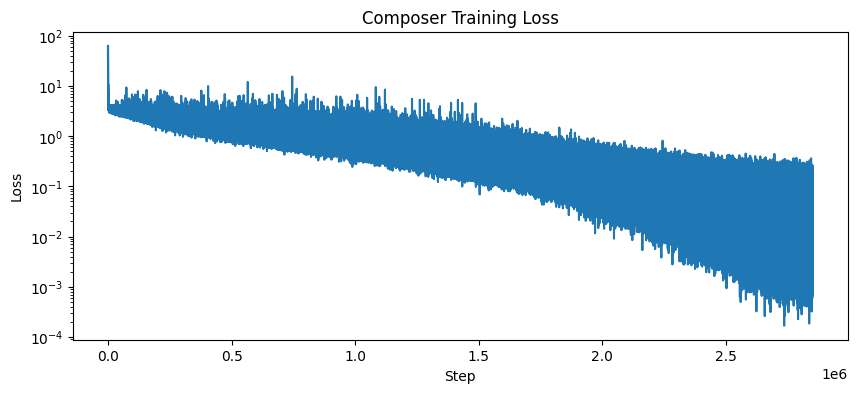

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(align_results['loss_history'])
plt.yscale('log')
plt.title('Composer Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

### Composer Training Evals

In [8]:
eval_config = {
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim,
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': composer_cfg.batch_size, 'seed': SEED
}
model.eval()
align_eval_ctx = EvalContext(config=eval_config, data_root=data_cfg.data_root, checkpoint_root=data_cfg.data_root, ref_dir=data_cfg.ref_dir)
align_eval_ctx._biojepa = model
align_eval_results = run_composer_evals(align_eval_ctx)
align_eval_ctx._biojepa = None

save_report(align_eval_results, data_cfg.eval_results_dir / 'composer_eval_report.json')
align_eval_results

Using cpu
Loaded 10791 v0.7 alignment pairs
Loaded DNA seq bank: torch.Size([11643, 1536])
Loaded chemical seq bank: torch.Size([188, 1536])
Encoded DNA sequences: torch.Size([11643, 128])
Encoded chemical sequences: torch.Size([188, 128])
Loaded target bank: torch.Size([9975, 320])
Encoded protein targets: torch.Size([9975, 128])
seq_to_target_retrieval: dna_mrr=0.4664
cross_modality_target_consistency: Within=0.6939, Between=0.6243, Ratio=1.11x
seq_target_gap_analysis: dna_gap=0.80
paired_alignment_quality: dna_sim=0.8137
mode_sensitivity: Classification_acc=0.6690 (4.7x chance)
mode_semantic_consistency: semantic_gap=0.0082, cross_mode_mrr=0.0660
fusion_quality: Fused_var=0.5673, Seq_var=0.4294, Target_var=0.0817
missing_data_robustness: Fused_MRR=0.9197, Seq_only=0.4728, Target_only=0.9925
found 135 shards for split test


multi_pert_alignment: Scanning for multi-pert: 100%|████████████| 500/500 [00:02<00:00, 184.80it/s]


Loaded 27264 HGNC gene family annotations
target_family_probing: seq_only=0.0945, target_only=0.2056, fused=0.2199
Loading KEGG_2026...
  352 pathways loaded
Loading Reactome_Pathways_2024...
  2100 pathways loaded
action_vector_pathways DNA: ratio=1.0021585603208807
Saved report to /Users/djemec/data/jepa/v0_7/eval_results/composer_eval_report.json


{'seq_to_target_retrieval': {'config': {'n_targets': 9975},
  'by_modality': {'dna': {'mrr': 0.4664176432639892,
    'median_rank': 3.0,
    'mean_rank': 89.09661335841956,
    'n_queries': 10630,
    'n_targets': 9975,
    'recall_at_k': {'1': 0.1942615239887112,
     '5': 0.913170272812794,
     '10': 0.9792097836312323,
     '20': 0.98137347130762,
     '50': 0.981749764816557}}}},
 'cross_modality_target_consistency': {'config': {'n_valid_targets': 921,
   'n_within_pairs': 1408,
   'n_between_pairs': 5000},
  'metrics': {'within_target_sim': 0.6938861608505249,
   'between_target_sim': 0.6243482818126679,
   'consistency_ratio': 1.1113767444605884}},
 'seq_target_gap_analysis': {'target_variance': 10.31498908996582,
  'n_targets': 9975,
  'dna': {'seq_variance': 57.093746185302734,
   'centroid_distance': 2.4022862911224365,
   'mean_within_seq': 10.670425254948345,
   'mean_seq_to_target': 8.509254455566406,
   'gap_ratio': 0.7974616055363203,
   'n_sequences': 11643}},
 'paired_

In [ ]:
del comp_train_loader, comp_val_loader, align_eval_ctx
gc.collect()
torch.cuda.empty_cache()
model.train()

## Stage 3: AC Training

In [ ]:
train_loader = TrainingLoader(
    batch_size=ac_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'predictor_t', 
    device=device)
val_loader = TrainingLoader(
    batch_size=ac_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'predictor_t', 
    device=device)

full_results = run_ac_training(model, train_loader, val_loader, seq_banks, target_bank, ac_cfg, device, data_cfg.checkpoint_dir, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED)

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(full_results['loss_history'])
plt.title('AC Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

In [ ]:
del train_loader, val_loader
gc.collect()
torch.cuda.empty_cache()

## Linear Decoder Training

In [ ]:
decoder_train_loader = TrainingLoader(
    batch_size=decoder_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'predictor_t', 
    device=device)
decoder_val_loader = TrainingLoader(
    batch_size=decoder_cfg.batch_size,
    split='val', data_dir=data_cfg.data_root / 'predictor_t',
    device=device)

decoder, decoder_results = train_linear_decoder(model, decoder_train_loader, decoder_val_loader, seq_banks, target_bank, model_cfg, device, data_cfg.checkpoint_dir, decoder_cfg, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED)

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(decoder_results['loss_history'])
plt.title('Decoder Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

## AC Evals

In [ ]:
eval_config = {
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim,
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': ac_cfg.batch_size, 'seed': SEED
}
model.eval()
eval_ctx = EvalContext(config=eval_config, data_root=data_cfg.data_root, checkpoint_root=data_cfg.data_root, ref_dir=data_cfg.ref_dir)
eval_ctx._biojepa = model
eval_ctx._decoder = decoder
full_eval_results = run_ac_evals(eval_ctx)
eval_ctx._biojepa = None

save_report(full_eval_results, data_cfg.eval_results_dir / 'ac_eval_report.json')
full_eval_results

In [ ]:
del decoder_train_loader, decoder_val_loader, eval_ctx
gc.collect()
torch.cuda.empty_cache()

## Summary

In [ ]:
print('=== Training Complete ===')
print(f'Encoder training final loss: {pt_results["final_loss"]:.5f}')
print(f'Composer training final loss: {align_results["final_loss"]:.5f}')
print(f'AC training final loss: {full_results["final_loss"]:.5f}')
print(f'Decoder final loss: {decoder_results["final_loss"]:.5f}')
print(f'\nCheckpoints saved to: {data_cfg.checkpoint_dir}')
print(f'Eval reports saved to: {data_cfg.eval_results_dir}')